Neuromorphic engineering I

## Lab 10: Winner-Take-All circuit

Group number: 25

Team member 1: Kalle Falk

Team member 2: Marius Fauteux

Date: 11/11-2025

-------------------------------------------------------------------------------------------------------------------

The _winner-take-all_ (_WTA_) circuit models a neural network consisting
of **$N$** excitatory cells and one inhibitory cell, as depicted in <a href="#fig:01:wta-network">Figure 1</a>. When the excitatory
cells are active, they excite the inhibitory cell which in turn
inhibits all excitatory cells. The inhibitory cell's activity will
increase until it silences all excitatory cells but one.  If
the network loop gain is high enough, this excitatory cell is able to
maintain the required inhibitory cell activity by itself.
Naturally, the excitatory cell that survives is the one with the
largest extrinsic input.

A useful extension of the WTA network is the introduction of
positive feedback and lateral coupling through
both excitatory and (local) inhibitory nearest neighbor interactions. 
The positive feedback variant of the classical WTA 
network shows a hysteretic behavior
in the selection/de-selection mechanism, and is therefore denoted
the hysteretic winner-take-all (**HWTA**) network.


In this lab, we will investigate properties of both the classical WTA and
HWTA circuits.  Circuit schematics of a single cell
in the WTA and HWTA networks are
shown in <a href="#fig:02:wta-schematic">Figure 2</a>.
We will first characterize the
response properties of the classical WTA circuit and then compare the
effect of the various circuit additions to the HWTA circuit.
Furthermore we will investigate the effect of the coupling
diffusor circuits in the HWTA circuit. These diffusors implement
both lateral excitatory and inhibitory coupling between the cells.


<div id="fig:01:wta-network"
        style=" border-radius: 5px;
                border: 1px solid rgba(0,0,0,0.1);
                padding: 1em;
    ">

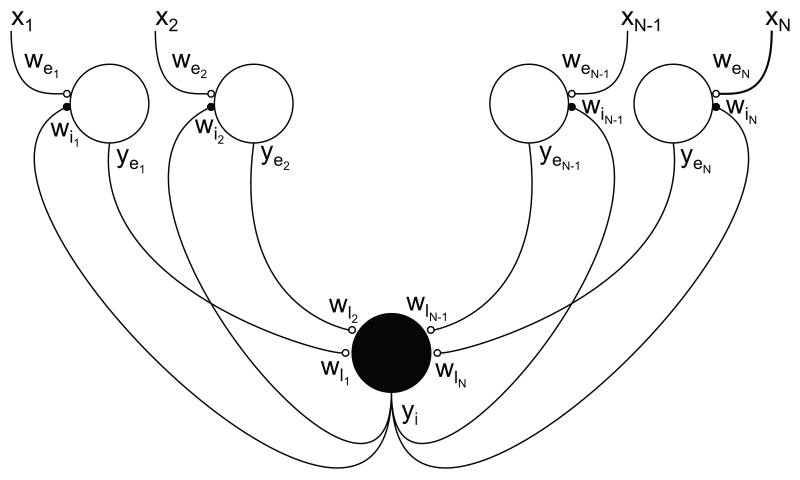

**Figure 1**: Network of **$N$** excitatory neurons _(empty circles)_ projecting to
one common inhibitory neuron _(filled circle)_, which provides feedback inhibition.
_Small filled circles_ indicate **inhibitory** synapses and _small empty circles_
indicate **excitatory** synapses.

$x_{1}\cdots x_{N}$ are external inputs; $y_{e1}\cdots y_{eN}$ are the outputs of
the excitatory neurons; $y_i$ is the output of the inhibitory neuron; $w_{e1}\cdots w_{eN}$
are the excitatory synaptic weights of the external inputs; $w_{l1} \cdots w_{lN}$
are the excitatory weights onto the global inhibitory neuron; and $w_{i1} \cdots w_{iN}$
neuron onto the excitatory neurons.

\[[Liu, S. Kramer, J. Indiveri, G. Delbrück, T. Douglas, R. (2002) Analog VLSI: Circuits and Principles. MIT Press. p. 152 (Figure 6.5)](https://doi.org/10.7551/mitpress/1250.001.0001)]

</div>

<div id="fig:02:wta-schematic"
    style=" border-radius: 5px;
                border: 1px solid rgba(0,0,0,0.1);
                padding: 1em;
    ">

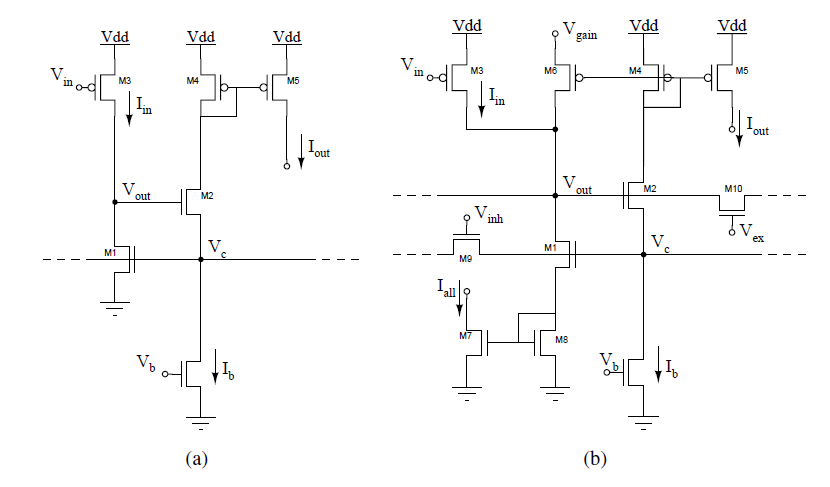

**Figure 2**: (a) Schematic of a single cell of a classical WTA network. (b) Schematic of a
single cell of a HWTA network.

</div>

# 1 Reading

Study the handouts and read the following papers:

- [**Indiveri, 2001** A current-mode hysteretic winner-take-all network, with excitatory and inhibitory coupling](https://doi.org/10.1023/A:1011208127849)
- [**Douglas, Martin 2007** Recurrent neuronal circuits in the neocortex](https://doi.org/10.1016/j.cub.2007.04.024)


# 2 Prelab

This prelab will help you develop intuition for the input-output
current relationship of the network.
We suggest you read the entire Prelab to 
understand the chain of reasoning before attempting
to answer the questions. Assume subthreshold operation unless otherwise
stated.


1. To begin, let's consider the 2-node WTA network in
<a href="#fig:03:2node-wta-schematic">Figure 3</a>.
Note that the WTA bias current $I_b$ is identical for both cells
_(they share the same bias voltage $V_b$)_.
Also note that node $V_c$ is common to both
cells. This common node is crucial, as it is through this node that
the global competition takes place. 



<div id="fig:03:2node-wta-schematic"
    style=" border-radius: 5px;
                border: 1px solid rgba(0,0,0,0.1);
                padding: 1em;
    ">

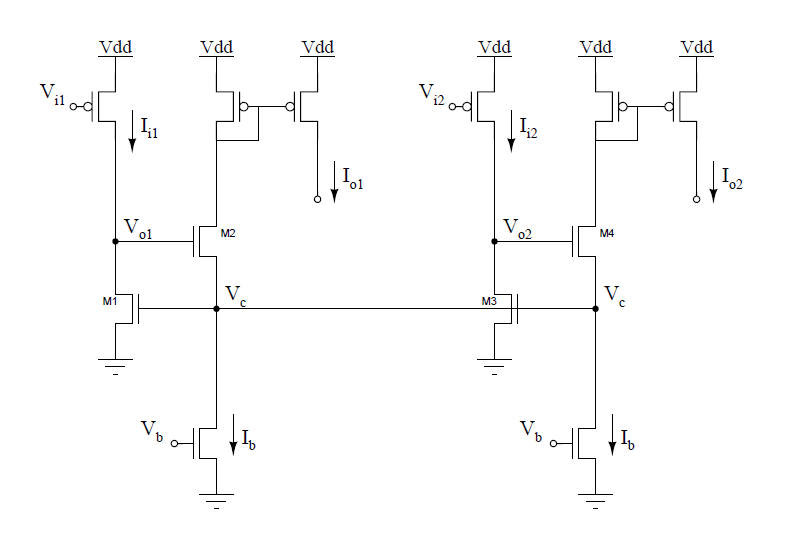

**Figure 3**: Schematic of a 2-node WTA network.

</div>

- <font color=#108ee9> Write down the equations for the (subthreshold) currents flowing through transistors M1
and M3, as a function of their gate, source and drain voltages,
separating their _forward_ and _reverse_ components. </font>

_Don't take into account, for the time being, the Early effect in the equations._

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">
The setup for M1 and M3 are similar, therefore the fomrula for the currents flowing thorgh are the same, with the folliwng relation for the revers and forward current components:

$$
I = I_f-I_r   \quad  (1)
$$
forward is defined as the current flowing from drain to sourse which is given as:

$$
I_{ds} = I_0 \cdot e^{\frac{\kappa V_g-V_s}{U_T}}   \quad     (2)
$$

Where as reverse is the opposite dierction going from source 
$$
I_{sd} = I_0 \cdot e^{\frac{\kappa V_g-V_d}{U_T}}         \quad (3)     
$$


Putting these into equation 1 we get
$$
I =  I_0 \cdot e^{\frac{\kappa V_g-V_s}{U_T}}  - I_0 \cdot e^{\frac{\kappa V_g-V_d}{U_T}} = I_0 \cdot e^{\frac{\kappa V_g}{U_T}} \left(e^{\frac{-V_s}{U_T}} - e^{\frac{-V_d}{U_T}} \right)

$$

</div>

- <font color=#108ee9> Calculate $V_c$, $V_{o1}$ and $V_{o2}$ , $I_{o1}$ and $I_{o2}$
considering that the gate voltages of M1 and M3 are the same, under the condition
**$I_{i1} = I_{i2} = I_{in}$**.  </font>

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">
for this answer we conferred page 161 of the textbook

If $V_c$ is the same, and the inputs are equal, then from the symmetry we get that $V_{o1}$ and $V_{o2}$ must also be the same. Since these gate voltages are the same, the symmetry again tells us that the current flowing through M2 and M4 must be the same, since their drain voltage ($V_{dd}$), source voltage ($V_c$) and gate voltage ($V_{o1}=V_{o2}$) are all the same. For kirchoffs 2nd law to be satisfied we get that $I_b = I_{out1}+I_{out2}$, and since they are the same we get that
$$
I_{out1}=I_{out2}=\frac{I_b}{2}
$$

</div>

- <font color=#108ee9>Generalize your result for $N$ cells.</font>

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">
For N identical cells tied to the same competition node $V_c$ and the inputs are all equal (perfect symmetry), then KCL at $V_c$ gives

$$
\sum_{k=1}^{N} I_{\text{out},k} = I_b
\;\Longrightarrow\;
\boxed{\,I_{\text{out},k}=\dfrac{I_b}{N}\; \text{for all } k\, }.
$$

All cell node voltages are equal:

$$
\boxed{\,V_{o1}=V_{o2}=\cdots=V_{oN}\equiv V_o\,}, \qquad
\boxed{\,V_c \text{ common to all.}\,}
$$

Relating $V_o$ and $V_c$ (subthreshold, no Early effect) for any branch $k$:

$$
\frac{I_b}{N}
= I_0 \exp\!\left(\frac{\kappa V_o}{U_T}\right)
\left(1 - e^{-V_c/U_T}\right).
$$

</div>

- <font color=#108ee9>Calculate $V_c$ , $V_{o1}$ and $V_{o2}$ , $I_{o1}$ and $I_{o2}$</font>
considering that the gate voltages of M1 and M3 are the same, under the condition
**$I_{i1} \gg I_{i2}$**.

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">

Looking at the schematic, we'll notice how a high $I_{i1}$ result in a high $V_{o1}$ (in this case $V_{o1}=ln(I_{i1})$). This high gate voltage on M2 results in increase in $V_c$.

The high $V_c$ on M3 tells us that the drain to source voltage across should be low since the current passing thorugh is low (**$I_{i2} \ll I_{i1}$**). As source is ground, this means that thw drain voltage $V_{o2}$ also goes towards ground ($V_{o2}<4\cdot U_T$). For this case M4 stops conducting - it is closed of, so that $I_{o2}$ discharges and can't see into Ib. 

Since $I_{i1}+I_{i2}=I_{b}$ we get that
$$
I_{i1} = I_{b}
$$

</div>

- <font color=#108ee9>Generalize your result for $N$ cells.</font>

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">
    Still the same, the cell with highest current input will take all of I_b for the output
</div>

2. The analysis above applies when the input currents are sufficiently different.
To understand what happens when the inputs are very similar, we have to take into account
the Early effect on devices M1 and M3.

    Let's do a small-signal analysis:
    - Initially, the input currents are equal, $I_{i1}=I_{i2}=I_{in},$ and therefore the
    outputs are equal, $I_{o_1}=I_{o_2}=I_b$.
    - A small differential input $\Delta{I_{in}}$
    is then applied, ie the inputs are now $I_u\pm\frac{1}{2}\Delta{I_{in}}$.
    - <font color=#108ee9>What is the differential output, $\Delta{V}_{out}$?</font>
    - <font color=#108ee9>To help you in your reasoning, draw a transistor's
    subthreshold $I_{ds}$ vs. $V_{ds}$ curve.</font>

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">
To analyze the circuit in this regime, we must consider the Early effect of the transistor operating in the saturation region

$$
I_{ds} = I_{\text{sat}} \left( 1 + \frac{V_{ds}}{V_e} \right)
$$

where $V_e$ is the Early voltage.

Assume that the two input currents $I_{in1}$ and $I_{in2}$ are initially equal.  
In this case, the transistors M1 and M2 operate in the saturation region:  
the output voltages $V_{d1}$ and $V_{d2}$ will settle to a common value, and the output currents $I_{out1}$ and $I_{out2}$ will both be equal to $I_b/2$.

If we now increase the input current $I_{in1}$ by a small amount $\delta I$ and apply Eq. 3.5.3 to transistor M1 of Fig. 6.8, then its drain voltage $V_{d1}$ will increase by

$$
\delta V = \frac{\delta I}{I_{\text{sat}}} \, V_e .
$$

As $V_{d1}$ is also the gate voltage of transistor M3, the $I_{out,1}$ will be amplified by an amount proportional to $e^{\delta V}$.  
The constraint of Kirchoffs 2nd law at the $V_c$ node requires that $I_{out2}$ decrease by the same amount in steady state.  
This reduction means the gate voltage $V_{d2}$ of M4 must decrease by $\delta V$.

The gain of the competition mechanism $\left( \frac{\delta V}{\delta I} \right)$ in the small-signal regime is directly proportional to the Early voltage $V_e$ and inversely proportional to $I_{\text{sat}}$.  
The Early voltage depends on the geometry of the transistors and is fixed at design time.  
On the other hand, $I_{\text{sat}}$ depends on $V_c$, which changes with the amplitude of the input currents.

</div>

- Assume that $V_c$ does not change. Given that the drain conductance of M1 and M3 is $g_{\rm d}$, <font color=#108ee9>how much do $V_{o1}$ and $V_{o2}$ need to change in order to accomodate the change in current?</font>

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">
    
For a constant $V_c$, a small differential change is constranied by the follwing relationship

$$
I_{in1} = I_{in} + \frac{1}{2}\Delta I, \qquad
I_{in2} = I_{in} - \frac{1}{2}\Delta I
$$

which must be accommodated by small changes in the node voltages $V_{o1}$ and $V_{o2}$, given that the competition node $V_c$ is fixed.

Both bottom transistors (M1 and M3) have the same output conductance $g_d$.


For a MOSFET in saturation including the Early effect:

$$
i_d = g_d\, v_{ds}
$$

Thus, in small-signal form:

- For M1 (left branch):

  $$
  \delta I_{M1} = g_d\,\delta V_{o1}
  $$

- For M3 (right branch):

  $$
  \delta I_{M3} = g_d\,\delta V_{o2}
  $$

because $V_c$ is fixed.

By definition:

$$
\delta I_{out,1} = +\frac{1}{2}\Delta I, \qquad
\delta I_{out,2} = -\frac{1}{2}\Delta I
$$

KCL at each output node states:

$$
\delta I_{out,k} = \delta I_{in,k} - \delta I_{Mk}
$$

For branch 1:

$$
\frac{1}{2}\Delta I
= \frac{1}{2}\Delta I - g_d\,\delta V_{o1}
$$

This implies the change is fully balanced at that node.  
The effective constraint actually comes from KCL at the shared node $V_c$.

At symmetry, both M1 and M3 carry equal DC current.  
With a differential input, their currents change oppositely:

$$
\delta I_{M1} = +\frac{1}{2}\Delta I, \qquad
\delta I_{M3} = -\frac{1}{2}\Delta I
$$

Using the small-signal relations:

$$
\delta I_{M1} = g_d\,\delta V_{o1}, \qquad
\delta I_{M3} = g_d\,\delta V_{o2}
$$

We obtain:

$$
g_d\,\delta V_{o1} = +\frac{1}{2}\Delta I
$$

$$
g_d\,\delta V_{o2} = -\frac{1}{2}\Delta I
$$


$$
\delta V_{o1} = \frac{\Delta I}{2 g_d}, \qquad
\delta V_{o2} = -\frac{\Delta I}{2 g_d}
$$

Thus, the differential output voltage is:

$$
\Delta V_o = \delta V_{o1} - \delta V_{o2}
= \frac{\Delta I}{g_d}
$$

- Larger Early effect gives larger $g_d$, which reduces the required voltage swing.
- Smaller $g_d$ (better saturation) increases the required voltage swing.

This shows the WTA small-signal gain depends directly on the Early effect.

</div>

- <font color=#108ee9>Given these changes, use the small-signal transconductance
$g_{\rm m}$ of M2 and M4 to
figure out how much the output currents will change.</font>

    _Assume that $I_{i1} = I_{i2} = I_u$ and $I_{b}$ are in the same order of magnitude
    (e.g. $ I_{u} / I_{b} \approx$  1 ), early voltage of M1 and M3 is
    $V_e$ = 25V, $U_T$ = 25mV, $\kappa$ = 1._

For subthreshold MOSFETs in saturation:

$$
I_{DS} = I_0 e^{(\kappa V_G - V_S)/U_T}
$$

$$
g_m \;\dot{=}\; \frac{d}{dV_G} I_{DS}
     \;=\; \frac{\kappa}{U_T} I_{DS}
$$

And we also had
$$
I_{ds} = I_{\text{sat}} \left( 1 + \frac{V_{ds}}{V_e} \right)
$$


putting it all together we get:
$$
g_m \;\dot{=}\; \frac{\kappa}{U_T} I_{\text{sat}} \left( 1 + \frac{V_{ds}}{V_e} \right)
$$





3. The circuit on the CoACH chip has the circuit of
<a href="#fig:02:wta-schematic">Figure 2 (b)</a>, which has four differences from
<a href="#fig:02:wta-schematic">Figure 2 (a)</a>.
<font color=#108ee9>Try to explain what the additional components of (b), not
present in (a), do.</font>

* M6

What function does it implement?

M6 acts as a programmable gain element on the input current $I_{in,k}$ and serves as feedbback as it is modulated by the $I_{out,k}$ though a current mirror. It serves as positive feedback on the winner.

What should $V_{gain}$ be in order to disable this function?

Then $V_{gain}$ should be equal $V_{max}=V_{dd}$. This makes M6 operate in strong saturation (or even linear), giving nearly zero resistance, so the input passes unchanged.

What should $V_{gain}$ be in order to enable this function, and what is the effect?

To enable the function:

- Lower $V_{\text{gain}}$ so M6 partially conducts.

This puts M6 in subthreshold resulting in attenuation of $I_{in}$ which can then serve as increased nonlinearity / gain control


* M7 and M8

What function does it implement?

A currentmirror which sees the sum of all inputs from all neighboring cells and the cell where looking at.

---

* M9

What function does it implement?

Smoothes the output current by allowing lateral current flow.  M9 and M2 serves as a diffuser network for the smoothing.

What should $V_{inh}$ be in order to turn off this function?

Should be set to V_dd, this way M9 is essentially a fully conducting wire, so no smoothing/inhibition is performed

What should $V_{inh}$ be in order to turn on this function, and what is the effect?


To activate inhibition we should lower $V_{\text{inh}}$. The effect would be that:
- M9 partially cuts off M1  
- Raises its effective resistance  
- Cell loses competition strength  
- Output is suppressed  

This can be used for winner resetting, selective disabling, or **gated WTA behavior.

---


* M10

What function does it implement?

Smoothes the input current by allowing lateral current flow, M10 and M1 serves as a diffuser network. So M10 injects a current into the output path, controlled by $V_{ex}$, and thus it provides excitatory drive or additional offset current.

What should $V_{ex}$ be in order to turn off this function?

Set it to ground/0, then M10 is fully off and hence no excitatory current injection is fed to the output path

What should $V_{ex}$ be in order to turn on this function, and what is the effect?

To activate the function we should increase $V_{\text{ex}}$, which will result in M10 increasing its conductance resulting in:
- Extra current added to output  
- Raises output $V_{\text{out}}$ or $I_{\text{out}}$  
- Controls activation of the cell  
- Can bias the cell toward winning

---

# 3 Setup

Import necessary python libraries. The cell below may be collapsed.

In [1]:
import time # for time.sleep(seconds)
import numpy as np # numpy for arrays etc
from scipy import stats, interpolate # for stats.linregress
import matplotlib
import matplotlib.pyplot as plt # for plotting
import matplotlib
plt.rcParams.update({'font.size': 10}) # make the detault font size larger for your readers
matplotlib.rcParams['pdf.fonttype'] = 42 # save fonts as type that are not outlined in illustrator or other drawing programs
from engineering_notation import EngNumber as ef # format numbers in engineering format quickly, e.g. ef(2e-9)='2n' https://pypi.org/project/engineering-notation/
from pathlib import Path # used for saving data

datapath = Path('data/dvs') # make a data folder to save your data called data/lab5
datapath.mkdir(parents=True, exist_ok=True)
from jupyter_save_load_vars import savevars, loadvars
from tqdm import tqdm

from IPython.display import display, Markdown, Latex, clear_output

import pyplane # for type hinting of biasgen constants
from ne1 import Coach # import Coach() class
import logging
# below lines are notebook magic for debugging, you can uncomment them when debugging the Coach() class
%load_ext autoreload
%autoreload explicit
%aimport ne1


In [3]:
# create a Plane object and open the communication
c=Coach(logging_level=logging.INFO) # NOTE change to INFO to reduce clutter - create a Coach object called p; you will use it to talk to class chip, change to logging.DEBUG for troubleshooting
c.open()
p=c.get_pyplane() # this lab uses the low level plane object a lot

[INFO]: 2025-11-11 14:31:47,201 - NE1 - Opened CoACH at /dev/cu.usbmodem76219301 with firmware version (1, 12, 5) (File "/Users/jesperjorgen/Desktop/pappas_comp/1UNI/ETH/NE1/CoACH-LABS/ne1.py", line 175, in open)


<div style="border: 2px dotted blue; margin: 1em 0 1em 1em; padding: 1em 1em 0.5em 1em">
    
You may have noticed that there are some biases that are not used to directly 
generate a current, but rather what matters is the voltage, e.g. $V_{\rm gain}$, 
$V_{\rm ex}$ and $V_{\rm inh}$ in our HWTA circuit. 

Even though they may have a 
`BIAS_NAME` ending with `_N` or `_P` it only indicates that they are 
connected to the gate of an N- or a P-FET, but the `BIAS_TYPE` parameter can 
be both `_N` or `_P`. 

For example, setting a `_N` bias to `BIAS_TYPE = P` in 
the case of $I_{\rm b}=0$ will only make this voltage very close to $V_{\rm DD}$, which _is_ 
sometimes the designed use case.

</div>

## 3.3 Setup C2F and voltage output buffer

In [4]:
# setup C2F
c.setup_c2f()
# setup output rail-to-rail buffer
c.setup_r2r_buffer()

# 4 Calibration

## 4.1 Calibration of C2F channels for $I_{out}$

In order to calibrate each C2F channel more accurately, we construct a case when only the calibrated cell wins, so that all 16 $I_b$ flow through the winning channel.

### 4.1.1 Chip configuration

In [5]:
# Setup WTA to read Iout
c.setup_wta_iout()

### 4.1.2 Set fixed voltages

- In the following cell we set the values for the voltages $V_{\rm gain}$ , $V_{\rm ex}$ and $V_{\rm inh}$. <font color=#108ee9>What is the value we are setting to each of them?</font>

In [6]:
c.set_bias(
    pyplane.Coach.BiasAddress.WTA_VGAIN_P,
    pyplane.Coach.BiasType.P,
    pyplane.Coach.BiasGenMasterCurrent.I30nA,
    255
)

c.set_bias(
    pyplane.Coach.BiasAddress.WTA_VEX_N,
    pyplane.Coach.BiasType.N,
    pyplane.Coach.BiasGenMasterCurrent.I30nA,
    0
)

c.set_bias(
    pyplane.Coach.BiasAddress.WTA_VINH_N,
    pyplane.Coach.BiasType.P,
    pyplane.Coach.BiasGenMasterCurrent.I30nA,
    0
)

0.0

<div markdown="1" style=" border: 1px dashed magenta; border-radius: 5px; /*background-color: #d1a2a2; */ margin: 1em 0 1em 0em; padding: 1em 1em 0.5em 1em">
    
| Pin                 | Value        | Feature    | Status   |
| :------------------ | :-           | :-         | :-       |
| $V_{\rm gain}$      | $V_{\rm SS}$ | Hysteresis | Inactive |
| $V_{\rm ex}$        | $V_{\rm SS}$ | Excitation | Inactive |
| $V_{\rm inh}$       | $V_{\rm DD}$ | Inhibition | Active   |

_NOTE: Be carefull of the device type_

</div>

In [7]:
# define a few usefull constants
VDD = 1.8
VSS = 0.0

* What value should the $V_{in}$ of the non-winning cells take? 

In [8]:
V_lose = VDD
V_win = VSS
for i in tqdm(range(16)):
    p.set_voltage(c.WTA_VIN_CHANNELS[i], V_lose)
    time.sleep(0.2)

100%|██████████| 16/16 [00:03<00:00,  4.88it/s]


### 4.1.3 Data aquisition

For each cell, sweep the total bias current ($16 \cdot I_{\rm b}$ from 0 to 10 nA).
Because we don't need too high precision, and it takes $16\times$ the time, only 6 points (including 0) per channel is enough.

* We want to set an equal bias current $I_{\rm b_i}$ as bias for each cell of the
WTA. <font color=#108ee9>What is the expression for the bias current for the whole circuit?</font>. Assume a `MasterCurrent` of 460pA and express it parametrically as a function of $I_{\rm b_i}$.
* Write your result in the code block below at `(...)`.

    _Hint: remember to consider the sizing factor $w = 3$._

We got:

\begin{equation}
I_b = w\frac{BG_{fine}}{256}I_{BG_{master}}
\end{equation}
Where $I_{\rm BG_{\rm master}}$ is the `BiasGenMasterCurrent` $\in \left\{ 60~\rm{pA}, 460~\rm{pA}, 3.8~\rm{nA}, 30~\rm{nA}, 240~\rm{nA} \right\}$, $BG_{\rm fine}$ is the integer fine value $\in [0, 256)$

In [9]:
N_samples = 6
Ib = np.linspace(0, 10e-9, N_samples)
fine = np.round((Ib / 460e-12) * (256 / 3) / 16).astype(int)  #this is where the bias fine values are calculated

c2f_freqs = np.zeros([16, N_samples])

for i in tqdm(range(16)):
    p.set_voltage(c.WTA_VIN_CHANNELS[i], V_win)
    
    for j in range(N_samples):
        c.set_wta_bias_fine(fine[j])
        time.sleep(0.2)

        freqs = c.measure_c2f_freqs(0.1)  # read c2f values
        c2f_freqs[i][j] = freqs[i]

    p.set_voltage(c.WTA_VIN_CHANNELS[i], V_lose)


100%|██████████| 16/16 [00:34<00:00,  2.13s/it]


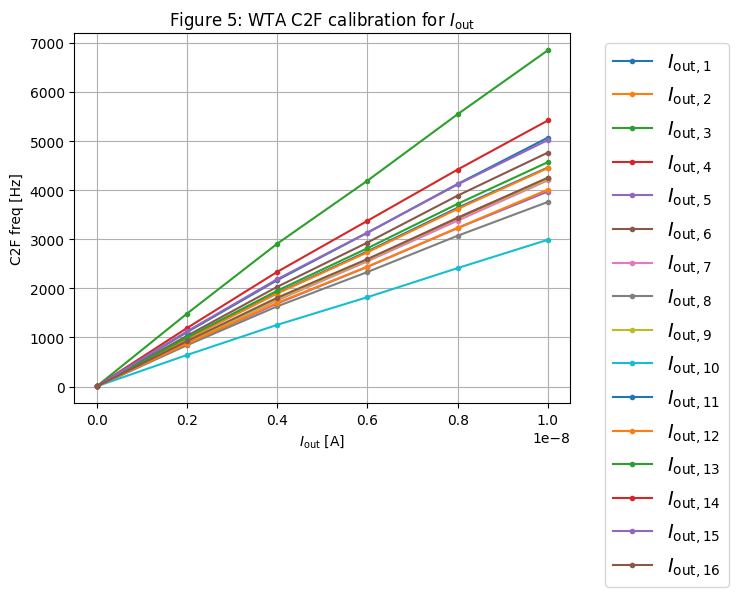

In [10]:
plt.plot(Ib, np.transpose(c2f_freqs), '.-')
plt.xlabel('$I_{\\rm out}$ [A]')
plt.ylabel('C2F freq [Hz]')
plt.title('Figure 5: WTA C2F calibration for $I_{\\rm out}$')
plt.legend([f"$I_{{\\rm out, {i+1} }}$" for i in range(16)], prop={'size': 14},bbox_to_anchor=(1.05, 1),loc='upper left') 
plt.grid()
plt.show()

In [11]:
c2f_wta_ch1  = np.polyfit(c2f_freqs[0], Ib,2)
c2f_wta_ch2  = np.polyfit(c2f_freqs[1], Ib,2)
c2f_wta_ch3  = np.polyfit(c2f_freqs[2], Ib,2)
c2f_wta_ch4  = np.polyfit(c2f_freqs[3], Ib,2)
c2f_wta_ch5  = np.polyfit(c2f_freqs[4], Ib,2)
c2f_wta_ch6  = np.polyfit(c2f_freqs[5], Ib,2)
c2f_wta_ch7  = np.polyfit(c2f_freqs[6], Ib,2)
c2f_wta_ch8  = np.polyfit(c2f_freqs[7], Ib,2)
c2f_wta_ch9  = np.polyfit(c2f_freqs[8], Ib,2)
c2f_wta_ch10 = np.polyfit(c2f_freqs[9], Ib,2)
c2f_wta_ch11 = np.polyfit(c2f_freqs[10],Ib,2)
c2f_wta_ch12 = np.polyfit(c2f_freqs[11],Ib,2)
c2f_wta_ch13 = np.polyfit(c2f_freqs[12],Ib,2)
c2f_wta_ch14 = np.polyfit(c2f_freqs[13],Ib,2)
c2f_wta_ch15 = np.polyfit(c2f_freqs[14],Ib,2)
c2f_wta_ch16 = np.polyfit(c2f_freqs[15],Ib,2)

c2f_wta_ch = [eval(f"c2f_wta_ch{i+1}") for i in range(16)]

In [12]:
# if the data looks nice, save it!
savevars(datapath/'c2f_calibration')

[INFO]: 2025-11-11 14:47:33,545 - saveloadvars - Saved to data/dvs/c2f_calibration.dill variables [ datapath VDD VSS V_lose V_win i N_samples Ib fine c2f_freqs j freqs c2f_wta_ch1 c2f_wta_ch2 c2f_wta_ch3 c2f_wta_ch4 c2f_wta_ch5 c2f_wta_ch6 c2f_wta_ch7 c2f_wta_ch8 c2f_wta_ch9 c2f_wta_ch10 c2f_wta_ch11 c2f_wta_ch12 c2f_wta_ch13 c2f_wta_ch14 c2f_wta_ch15 c2f_wta_ch16 ] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 2025-11-11 14:47:33,546 - saveloadvars - could not pickle: ['c', 'p', 'c2f_wta_ch'] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 221, in savevars)


In [ ]:
# maybe you need to load your saved data?
loadvars(datapath/'c2f_calibartion')

# 5 Basic WTA behavior

In this experiment, we will observe the winner–take–all network in action. We will only use cell 0 and 1 and disable all other cells.

<div style="border: 2px solid red; margin: 1em 0 1em 2em; padding: 1em 1em 0.5em 1em; border-radius: 5px">

<center>
    <b>
    Important
    </b>
</center>

Because all 16 channels are monitored by the C2F at the same 
time, if each channels has 50k events per second (this is the value 
everyone achieved in the last labs), it will result in almost 1M events per 
second in total, which is beyond the microcontroller's ability to handle 
and it will halt (and we have to repower it manually!). In order to 
prevent this situation, **please never set any $V_{in}$ below 1.5V!**

</red>

## 5.1 Set fixed voltages

In [13]:
c.set_wta_vgain(VSS)
c.set_wta_vex(VSS)
c.set_wta_vinh(VSS)
c.set_wta_bias_fine((5e-9 / 460e-12) * (256 / 3) / 16)

for i in tqdm(range(2, 16)):
    p.set_voltage(c.WTA_VIN_CHANNELS[i], VDD)
    time.sleep(0.2)

c.setup_wta_iout()

[INFO]: 2025-11-11 14:51:40,723 - NE1 - fine: 255 (File "/Users/jesperjorgen/Desktop/pappas_comp/1UNI/ETH/NE1/CoACH-LABS/ne1.py", line 1419, in set_wta_vgain)
100%|██████████| 14/14 [00:02<00:00,  4.87it/s]


## 5.2 Data aquisition

* Fix $V_{in,1}$ to a value and sweep $V_{in,0}$ from above $V_{in,1}$ to
below $V_{in,1}$ then to above $V_{in,1}$ again and observe the two
$V_{out}$ and $I_{out}$.

In [14]:
N_samples = 50

Vin_1 = 1.65
Vin_delta = 0.15
p.set_voltage(c.WTA_VIN_CHANNELS[1], Vin_1)
time.sleep(0.2)
Vin1_actual = p.get_set_voltage(c.WTA_VIN_CHANNELS[1])

Vin_0_set = np.concatenate(
    (
        np.linspace(Vin_1 - Vin_delta, Vin_1 + Vin_delta, 25),
        np.linspace(Vin_1 + Vin_delta, Vin_1 - Vin_delta, 25)
    )
)

Vin_0 = np.zeros(N_samples)
Vout_0 = np.zeros(N_samples)
Vout_1 = np.zeros(N_samples)
c2f_freqs_Iout = np.zeros([16, N_samples])

for j in tqdm(range(N_samples)):
    p.set_voltage(c.WTA_VIN_CHANNELS[0], Vin_0_set[j])
    time.sleep(0.2)

    Vin_0[j] = p.get_set_voltage(c.WTA_VIN_CHANNELS[0])
    time.sleep(0.1)
    
    Vout_0[j] = p.read_voltage(c.WTA_LVOUT_CHANNELS[0])
    Vout_1[j] = p.read_voltage(c.WTA_LVOUT_CHANNELS[1])
    
    # Measure Iout by c2f
    c2f_freqs_Iout[:,j] = c.measure_c2f_freqs(0.1)   

100%|██████████| 50/50 [00:20<00:00,  2.44it/s]


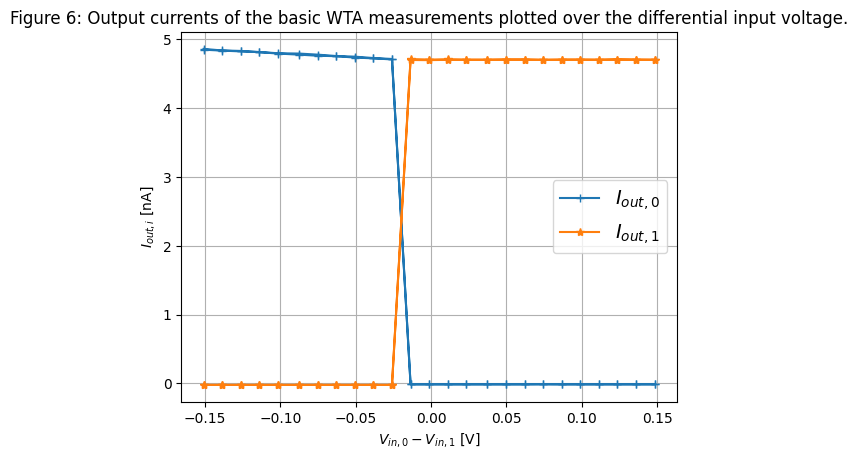

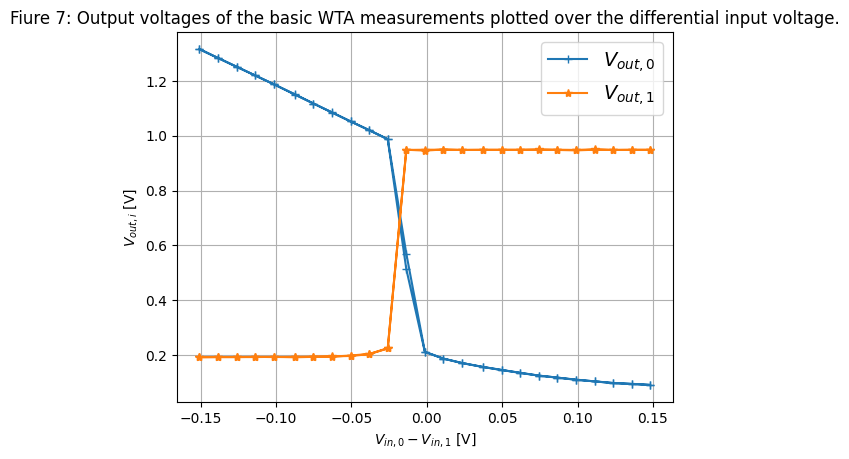

In [ ]:
Iout_0 = c2f_wta_ch1[2] + \
         c2f_wta_ch1[1] * c2f_freqs_Iout[0,:] + \
         c2f_wta_ch1[0] * c2f_freqs_Iout[0,:] ** 2
Iout_1 = c2f_wta_ch2[2] + \
         c2f_wta_ch2[1] * c2f_freqs_Iout[1,:] + \
         c2f_wta_ch2[0] * c2f_freqs_Iout[1,:] ** 2

# Plot output current vs. the difference between input voltages
plt.plot(Vin_0 - Vin_1, Iout_0*10**9, '+-')
plt.plot(Vin_0 - Vin_1, Iout_1*10**9, '*-')
plt.xlabel('$V_{in,0}-V_{in,1}$ [V]')
plt.ylabel('$I_{out,i}$ [nA]')
plt.legend(['${I_{out,0}}$','${I_{out,1}}$'],prop={'size': 14})           
plt.title('Figure 6: Output currents of the basic WTA measurements plotted over the differential input voltage.')
plt.grid()
plt.show()

plt.plot(Vin_0 - Vin_1, Vout_0, '+-')
plt.plot(Vin_0 - Vin_1, Vout_1, '*-')
plt.xlabel('$V_{in,0}-V_{in,1}$ [V]')
plt.ylabel('$V_{out,i}$ [V]')
plt.legend(['${V_{out,0}}$','${V_{out,1}}$'],prop={'size': 14})           
plt.title('Fiure 7: Output voltages of the basic WTA measurements plotted over the differential input voltage.')
plt.grid()
plt.show()

In [16]:
# if the data looks nice, save it!
savevars(datapath/'wta')

[INFO]: 2025-11-11 14:55:21,433 - saveloadvars - Saved to data/dvs/wta.dill variables [ datapath VDD VSS V_lose V_win i N_samples Ib fine c2f_freqs j freqs c2f_wta_ch1 c2f_wta_ch2 c2f_wta_ch3 c2f_wta_ch4 c2f_wta_ch5 c2f_wta_ch6 c2f_wta_ch7 c2f_wta_ch8 c2f_wta_ch9 c2f_wta_ch10 c2f_wta_ch11 c2f_wta_ch12 c2f_wta_ch13 c2f_wta_ch14 c2f_wta_ch15 c2f_wta_ch16 Vin_1 Vin_delta Vin1_actual Vin_0_set Vin_0 Vout_0 Vout_1 c2f_freqs_Iout Iout_0 Iout_1 ] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 2025-11-11 14:55:21,433 - saveloadvars - could not pickle: ['c', 'p', 'c2f_wta_ch'] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 221, in savevars)


In [ ]:
# maybe you need to load your saved data?
loadvars(datapath/'wta')

- <font color=#108ee9>What would happen to the above plots if you were to change the bias current?</font> Validate your answer in the following section.

We increase the Gain of the circuit. The winner cell's $I_{out}$ will therefore be higher at higher $I_b$

## 5.3 Bias current dependency

The following code blocks are almost identical to the previous section. Define some sensible values for `wta_ib_values` that will be iterated over to investigate the device behaviour.

In [18]:
c.set_wta_vgain(VSS)
c.set_wta_vex(VSS)
c.set_wta_vinh(VSS)

wta_ib_values = [2.5e-9, 5e-9, 7.5e-9]

c.setup_wta_iout()

[INFO]: 2025-11-11 15:07:10,559 - NE1 - fine: 255 (File "/Users/jesperjorgen/Desktop/pappas_comp/1UNI/ETH/NE1/CoACH-LABS/ne1.py", line 1419, in set_wta_vgain)


In [19]:
N_samples = 50

Vin_1 = 1.65
Vin_delta = 0.15
p.set_voltage(c.WTA_VIN_CHANNELS[1], Vin_1)
time.sleep(0.2)
Vin1_actual = p.get_set_voltage(c.WTA_VIN_CHANNELS[1])

Vin_0_set = np.concatenate(
    (
        np.linspace(Vin_1 - Vin_delta, Vin_1 + Vin_delta, 25),
        np.linspace(Vin_1 + Vin_delta, Vin_1 - Vin_delta, 25)
    )
)

Vin_0 =  np.zeros([len(wta_ib_values), N_samples])
Vout_0 = np.zeros([len(wta_ib_values), N_samples])
Vout_1 = np.zeros([len(wta_ib_values), N_samples])
c2f_freqs_Iout = np.zeros([len(wta_ib_values), 16, N_samples])

for idx, ib in enumerate(wta_ib_values):
    c.set_wta_bias_fine((ib / 460e-12) * (256 / 3) / 16)
    time.sleep(0.2)
    for i in tqdm(range(2, 16)):
        p.set_voltage(c.WTA_VIN_CHANNELS[i], VDD)
        time.sleep(0.2)
    
    for j in tqdm(range(N_samples)):
        p.set_voltage(c.WTA_VIN_CHANNELS[0], Vin_0_set[j])
        time.sleep(0.2)
    
        Vin_0[idx, j] = p.get_set_voltage(c.WTA_VIN_CHANNELS[0])
        time.sleep(0.1)
        
        Vout_0[idx, j] = p.read_voltage(c.WTA_LVOUT_CHANNELS[0])
        Vout_1[idx, j] = p.read_voltage(c.WTA_LVOUT_CHANNELS[1])
        
        # Measure Iout by c2f
        c2f_freqs_Iout[idx, :, j] = c.measure_c2f_freqs(0.1)   

    clear_output()

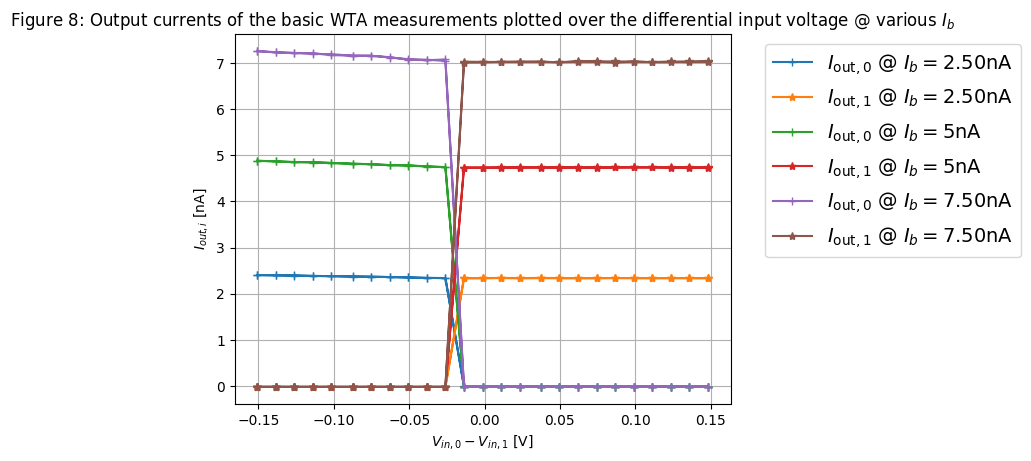

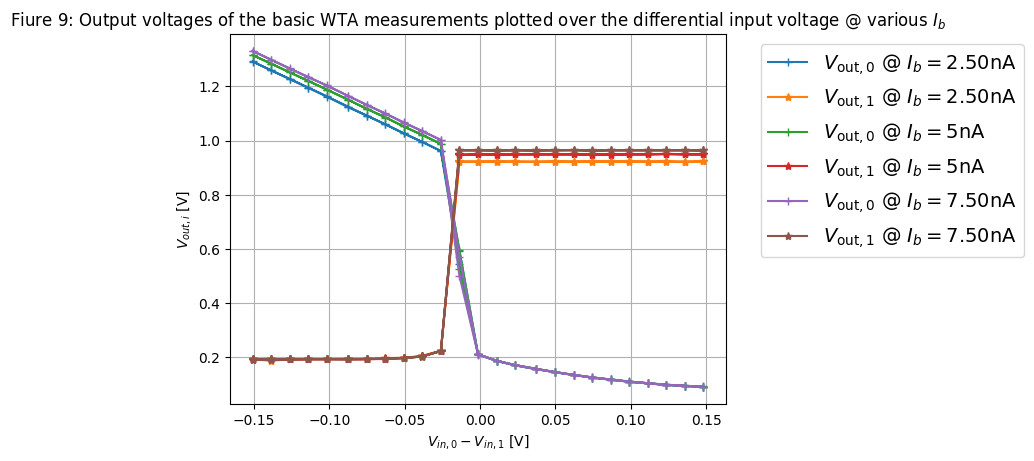

In [20]:
for idx, ib in enumerate(wta_ib_values):
    Iout_0 = c2f_wta_ch1[2] + \
             c2f_wta_ch1[1] * c2f_freqs_Iout[idx, 0, :] + \
             c2f_wta_ch1[0] * c2f_freqs_Iout[idx, 0, :] ** 2
    Iout_1 = c2f_wta_ch2[2] + \
             c2f_wta_ch2[1] * c2f_freqs_Iout[idx, 1, :] + \
             c2f_wta_ch2[0] * c2f_freqs_Iout[idx, 1, :] ** 2
    # Plot output current vs. the difference between input voltages
    plt.plot(Vin_0[idx] - Vin_1, Iout_0*10**9, '+-')
    plt.plot(Vin_0[idx] - Vin_1, Iout_1*10**9, '*-')
    
plt.xlabel('$V_{in,0}-V_{in,1}$ [V]')
plt.ylabel('$I_{out,i}$ [nA]')
plt.legend(
    [f'$I_{{\\rm out, {val} }}$ @ $I_b = {{\\rm {ef(curr)}A }}$' for curr in wta_ib_values for val in ['0', '1']],
    prop={'size':14},
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.title('Figure 8: Output currents of the basic WTA measurements plotted over the differential input voltage @ various $I_b$')
plt.grid()
plt.show()


    
for idx, ib in enumerate(wta_ib_values):
    plt.plot(Vin_0[idx] - Vin_1, Vout_0[idx], '+-')
    plt.plot(Vin_0[idx] - Vin_1, Vout_1[idx], '*-')
    
plt.xlabel('$V_{in,0}-V_{in,1}$ [V]')
plt.ylabel('$V_{out,i}$ [V]')
plt.legend(
    [f'$V_{{\\rm out, {val} }}$ @ $I_b = {{\\rm {ef(curr)}A }}$' for curr in wta_ib_values for val in ['0', '1']],
    prop={'size':14},
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
plt.title('Fiure 9: Output voltages of the basic WTA measurements plotted over the differential input voltage @ various $I_b$')
plt.grid()
plt.show()

In [21]:
# if the data looks nice, save it!
savevars(datapath/'wtaib')

[INFO]: 2025-11-11 15:16:13,506 - saveloadvars - Saved to data/dvs/wtaib.dill variables [ datapath VDD VSS V_lose V_win i N_samples Ib fine c2f_freqs j freqs c2f_wta_ch1 c2f_wta_ch2 c2f_wta_ch3 c2f_wta_ch4 c2f_wta_ch5 c2f_wta_ch6 c2f_wta_ch7 c2f_wta_ch8 c2f_wta_ch9 c2f_wta_ch10 c2f_wta_ch11 c2f_wta_ch12 c2f_wta_ch13 c2f_wta_ch14 c2f_wta_ch15 c2f_wta_ch16 Vin_1 Vin_delta Vin1_actual Vin_0_set Vin_0 Vout_0 Vout_1 c2f_freqs_Iout Iout_0 Iout_1 wta_ib_values idx ib ] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 2025-11-11 15:16:13,507 - saveloadvars - could not pickle: ['c', 'p', 'c2f_wta_ch'] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 221, in savevars)


In [ ]:
# maybe you need to load your saved data?
loadvars(datapath/'wtaib')

# 6 Hysteretic WTA behavior

In this experiment, we will observe the winner–take–all network with 
hysteresis. This implies a "memory" effect.

Like before, we will still use only cell 0 and 1 and disable all other 
cells.

## 6.1 Set fixed voltages

Now just setting transistors on and off isn't enough, we need to set a proper
value to $V_{\rm gain}$. However, we must not think in terms of voltage, but current $I_{\rm gain}$.

In [22]:
#c.set_wta_vgain(VDD-0.1)
c.set_bias(
    pyplane.Coach.BiasAddress.WTA_VGAIN_P,
    pyplane.Coach.BiasType.P,
    pyplane.Coach.BiasGenMasterCurrent.I60pA,
    10
)

c.set_wta_vex(VSS)
c.set_wta_vinh(VSS)
c.set_wta_bias_fine((5e-9 / 460e-12) * (256 / 3) / 16)

for i in tqdm(range(2, 16)):
    p.set_voltage(c.WTA_VIN_CHANNELS[i], VDD)
    time.sleep(0.2)

c.setup_wta_iout()

100%|██████████| 14/14 [00:02<00:00,  4.87it/s]


## 6.2 Data aquisition

* Fix $V_{in,1}$ to a value and sweep $V_{in,0}$ from above $V_{in,1}$ to below $V_{in,1}$ then to above $V_{in,1}$ again and observe the two $V_{out}$, $I_{out}$ and $I_{all}$.

In [23]:
N_samples = 50

Vin_1 = 1.65
Vin_delta = 0.15
p.set_voltage(c.WTA_VIN_CHANNELS[1], Vin_1)
time.sleep(0.2)
Vin1_actual = p.get_set_voltage(c.WTA_VIN_CHANNELS[1])

Vin_0_set = np.concatenate(
    (
        np.linspace(Vin_1 - Vin_delta, Vin_1 + Vin_delta, 25),
        np.linspace(Vin_1 + Vin_delta, Vin_1 - Vin_delta, 25)
    )
)

Vin_0 = np.zeros(N_samples)
Vout_0 = np.zeros(N_samples)
Vout_1 = np.zeros(N_samples)
c2f_freqs_Iout = np.zeros([16, N_samples])

for j in tqdm(range(N_samples)):
    p.set_voltage(c.WTA_VIN_CHANNELS[0], Vin_0_set[j])
    time.sleep(0.2)

    Vin_0[j] = p.get_set_voltage(c.WTA_VIN_CHANNELS[0])
    time.sleep(0.1)
    
    Vout_0[j] = p.read_voltage(c.WTA_LVOUT_CHANNELS[0])
    Vout_1[j] = p.read_voltage(c.WTA_LVOUT_CHANNELS[1])
    
    # Measure Iout by c2f
    c2f_freqs_Iout[:,j] = c.measure_c2f_freqs(0.1) 

100%|██████████| 50/50 [00:20<00:00,  2.43it/s]


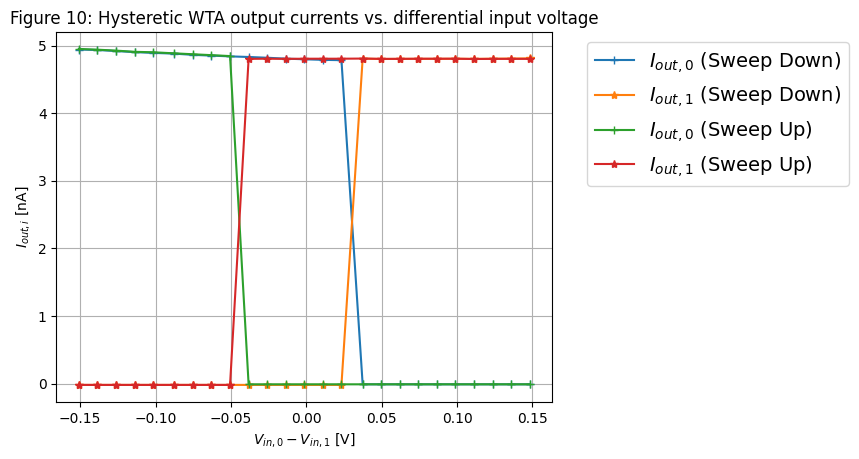

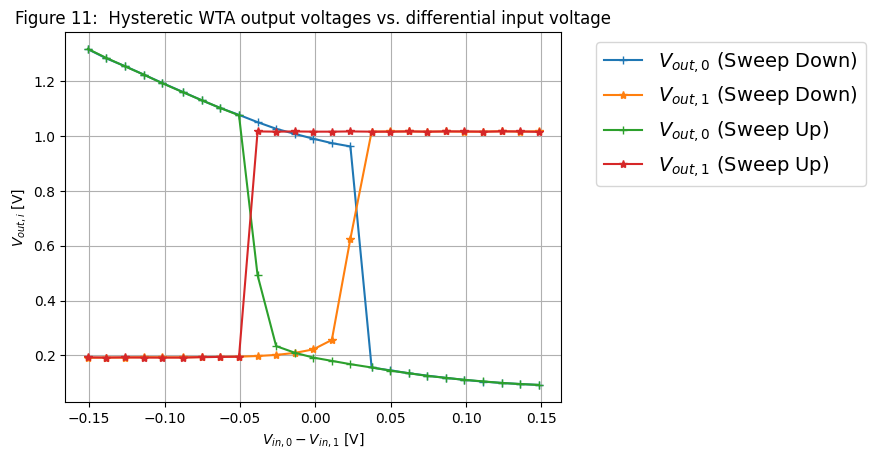

In [24]:
Iout_0 = c2f_wta_ch1[2] + \
         c2f_wta_ch1[1] * c2f_freqs_Iout[0,:] + \
         c2f_wta_ch1[0] * c2f_freqs_Iout[0,:] ** 2
Iout_1 = c2f_wta_ch2[2] + \
         c2f_wta_ch2[1] * c2f_freqs_Iout[1,:] + \
         c2f_wta_ch2[0] * c2f_freqs_Iout[1,:] ** 2

plt.plot((Vin_0 - Vin_1)[:N_samples//2], (Iout_0[:N_samples//2]) * 10**9, '+-')
plt.plot((Vin_0 - Vin_1)[:N_samples//2], (Iout_1[:N_samples//2]) * 10**9, '*-')
plt.plot((Vin_0 - Vin_1)[N_samples//2:], (Iout_0[N_samples//2:]) * 10**9, '+-')
plt.plot((Vin_0 - Vin_1)[N_samples//2:], (Iout_1[N_samples//2:]) * 10**9, '*-')
plt.legend([
    '${I_{out,0}}$ (Sweep Down)',
    '${I_{out,1}}$ (Sweep Down)',
    '${I_{out,0}}$ (Sweep Up)',
    '${I_{out,1}}$ (Sweep Up)'
],prop={'size': 14},bbox_to_anchor=(1.05, 1),loc='upper left')                     
plt.xlabel('$V_{in,0}-V_{in,1}$ [V]')
plt.ylabel('$I_{out,i}$ [nA]')
plt.title('Figure 10: Hysteretic WTA output currents vs. differential input voltage')
plt.grid()
plt.show()

plt.plot((Vin_0 - Vin_1)[:N_samples//2], Vout_0[:N_samples//2], '+-')
plt.plot((Vin_0 - Vin_1)[:N_samples//2], Vout_1[:N_samples//2], '*-')
plt.plot((Vin_0 - Vin_1)[N_samples//2:], Vout_0[N_samples//2:], '+-')
plt.plot((Vin_0 - Vin_1)[N_samples//2:], Vout_1[N_samples//2:], '*-')
plt.xlabel('$V_{in,0}-V_{in,1}$ [V]')
plt.ylabel('$V_{out,i}$ [V]')
plt.legend([
    '${V_{out,0}}$ (Sweep Down)',
    '${V_{out,1}}$ (Sweep Down)',
    '${V_{out,0}}$ (Sweep Up)',
    '${V_{out,1}}$ (Sweep Up)'
],prop={'size': 14},bbox_to_anchor=(1.05, 1),loc='upper left')                               
plt.title('Figure 11:  Hysteretic WTA output voltages vs. differential input voltage')
plt.grid()
plt.show()

In [25]:
# if the data looks nice, save it!
savevars(datapath/'hwta')

[INFO]: 2025-11-11 15:33:43,990 - saveloadvars - Saved to data/dvs/hwta.dill variables [ datapath VDD VSS V_lose V_win i N_samples Ib fine c2f_freqs j freqs c2f_wta_ch1 c2f_wta_ch2 c2f_wta_ch3 c2f_wta_ch4 c2f_wta_ch5 c2f_wta_ch6 c2f_wta_ch7 c2f_wta_ch8 c2f_wta_ch9 c2f_wta_ch10 c2f_wta_ch11 c2f_wta_ch12 c2f_wta_ch13 c2f_wta_ch14 c2f_wta_ch15 c2f_wta_ch16 Vin_1 Vin_delta Vin1_actual Vin_0_set Vin_0 Vout_0 Vout_1 c2f_freqs_Iout Iout_0 Iout_1 wta_ib_values idx ib ] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 2025-11-11 15:33:43,991 - saveloadvars - could not pickle: ['c', 'p', 'c2f_wta_ch'] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 221, in savevars)


In [ ]:
# maybe you need to load your saved data?
loadvars(datapath/'hwta')

## 6.3 Different gain voltages

The following code blocks are almost identical to the previous section. Define some sensible values for `wta_igain_fines` that will be iterated over to investigate the device behaviour.

In [26]:
c.set_wta_bias_fine((5e-9/ 460e-12) * (256 / 3) / 16)
c.set_wta_vex(VSS)
c.set_wta_vinh(VSS)

wta_igain_fines = [7, 10, 15, 20]

c.setup_wta_iout()

In [27]:
N_samples = 50

Vin_1 = 1.65
Vin_delta = 0.15
p.set_voltage(c.WTA_VIN_CHANNELS[1], Vin_1)
time.sleep(0.2)
Vin1_actual = p.get_set_voltage(c.WTA_VIN_CHANNELS[1])

Vin_0_set = np.concatenate(
    (
        np.linspace(Vin_1 - Vin_delta, Vin_1 + Vin_delta, 25),
        np.linspace(Vin_1 + Vin_delta, Vin_1 - Vin_delta, 25)
    )
)

Vin_0 =  np.zeros([len(wta_igain_fines), N_samples])
Vout_0 = np.zeros([len(wta_igain_fines), N_samples])
Vout_1 = np.zeros([len(wta_igain_fines), N_samples])
c2f_freqs_Iout = np.zeros([len(wta_igain_fines), 16, N_samples])

for idx, fine in enumerate(wta_igain_fines):
    
    c.set_bias(
        pyplane.Coach.BiasAddress.WTA_VGAIN_P,
        pyplane.Coach.BiasType.P,
        pyplane.Coach.BiasGenMasterCurrent.I60pA,
        fine
    )
    time.sleep(0.2)
    for i in tqdm(range(2, 16)):
        p.set_voltage(c.WTA_VIN_CHANNELS[i], VDD)
        time.sleep(0.2)
    
    for j in tqdm(range(N_samples)):
        p.set_voltage(c.WTA_VIN_CHANNELS[0], Vin_0_set[j])
        time.sleep(0.2)
    
        Vin_0[idx, j] = p.get_set_voltage(c.WTA_VIN_CHANNELS[0])
        time.sleep(0.1)
        
        Vout_0[idx, j] = p.read_voltage(c.WTA_LVOUT_CHANNELS[0])
        Vout_1[idx, j] = p.read_voltage(c.WTA_LVOUT_CHANNELS[1])
        
        # Measure Iout by c2f
        c2f_freqs_Iout[idx, :, j] = c.measure_c2f_freqs(0.1)   

    clear_output()

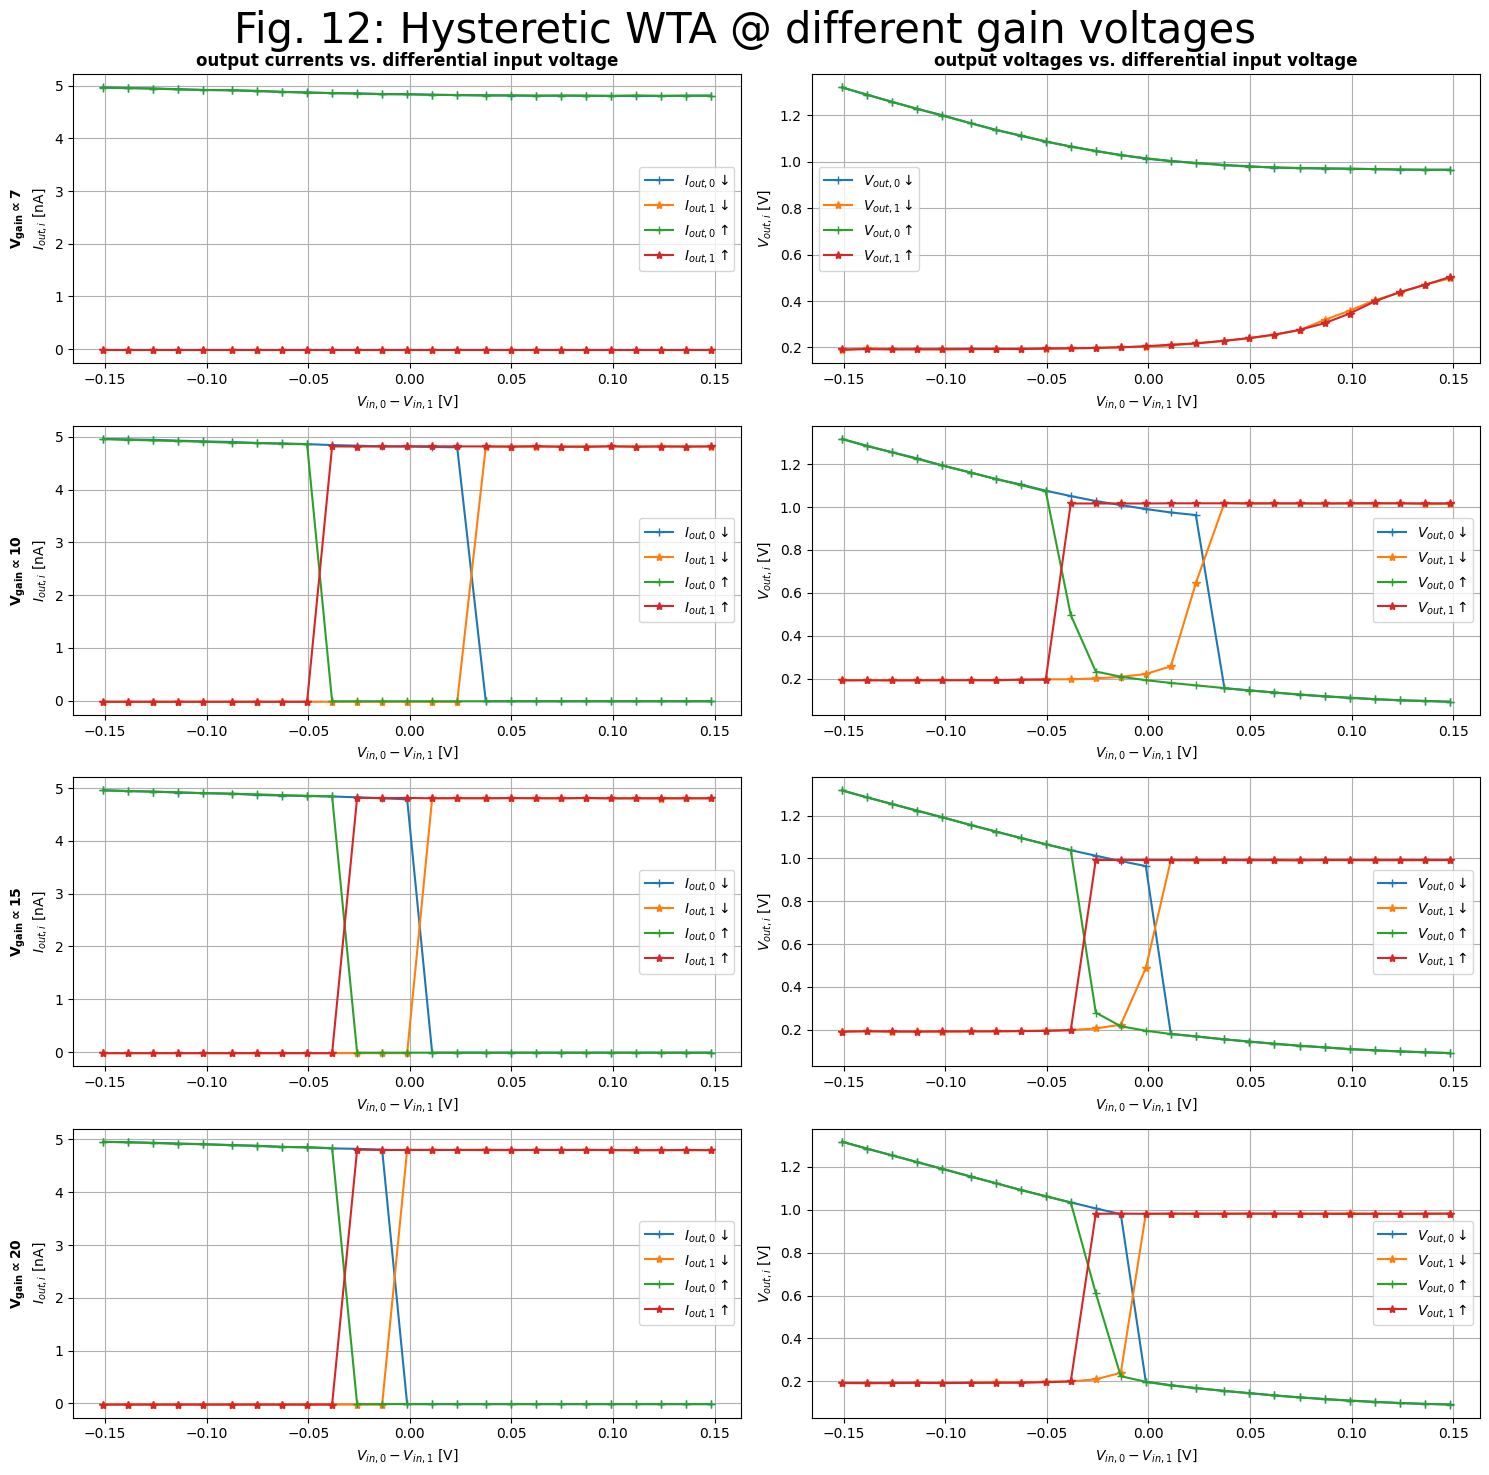

In [28]:
figure, axis = plt.subplots(len(wta_igain_fines), 2, figsize=(15, 15))

for idx, fine in enumerate(wta_igain_fines):
    Iout_0 =    c2f_wta_ch1[2] + \
                c2f_wta_ch1[1] * c2f_freqs_Iout[idx, 0, :] + \
                c2f_wta_ch1[0] * c2f_freqs_Iout[idx, 0, :] ** 2
    Iout_1 =    c2f_wta_ch2[2] + \
                c2f_wta_ch2[1] * c2f_freqs_Iout[idx, 1, :] + \
                c2f_wta_ch2[0] * c2f_freqs_Iout[idx, 1, :] ** 2
    
    axis[idx, 0].plot(Vin_0[idx][:N_samples//2] - Vin_1, Iout_0[:N_samples//2]*10**9, '+-')
    axis[idx, 0].plot(Vin_0[idx][:N_samples//2] - Vin_1, Iout_1[:N_samples//2]*10**9, '*-')
    axis[idx, 0].plot(Vin_0[idx][N_samples//2:] - Vin_1, Iout_0[N_samples//2:]*10**9, '+-')
    axis[idx, 0].plot(Vin_0[idx][N_samples//2:] - Vin_1, Iout_1[N_samples//2:]*10**9, '*-')
    axis[idx, 0].set(
        xlabel='$V_{in,0}-V_{in,1}$ [V]',
        ylabel=r"$\bf{V_{gain} \propto "+str(fine)+"}$\n$I_{out,i}$ [nA]"
    )
    axis[idx, 0].legend([
        r"${I_{out,0} \downarrow}$",
        r"${I_{out,1} \downarrow}$",
        r"${I_{out,0} \uparrow}$",
        r"${I_{out,1} \uparrow}$"
    ])
    axis[idx, 0].grid()
    
    axis[idx, 1].plot(Vin_0[idx][:N_samples//2] - Vin_1, Vout_0[idx][:N_samples//2], '+-')
    axis[idx, 1].plot(Vin_0[idx][:N_samples//2] - Vin_1, Vout_1[idx][:N_samples//2], '*-')
    axis[idx, 1].plot(Vin_0[idx][N_samples//2:] - Vin_1, Vout_0[idx][N_samples//2:], '+-')
    axis[idx, 1].plot(Vin_0[idx][N_samples//2:] - Vin_1, Vout_1[idx][N_samples//2:], '*-')
    axis[idx, 1].set(
        xlabel = '$V_{in,0}-V_{in,1}$ [V]',
        ylabel='$V_{out,i}$ [V]'
    )
    axis[idx, 1].legend([
        r"${V_{out,0} \downarrow}$",
        r"${V_{out,1} \downarrow}$",
        r"${V_{out,0} \uparrow}$",
        r"${V_{out,1} \uparrow}$"]
    )
    axis[idx, 1].grid()


axis[0, 0].set_title('output currents vs. differential input voltage', fontweight='bold')
axis[0, 1].set_title('output voltages vs. differential input voltage', fontweight='bold')
    
figure.suptitle('Fig. 12: Hysteretic WTA @ different gain voltages', fontsize=30)
figure.tight_layout()
plt.show()

In [ ]:
# if the data looks nice, save it!
savevars(datapath/'hwtaig')

[INFO]: 2025-11-11 15:36:01,125 - saveloadvars - Saved to data/dvs/hwtaig.dill variables [ datapath VDD VSS V_lose V_win i N_samples Ib fine c2f_freqs j freqs c2f_wta_ch1 c2f_wta_ch2 c2f_wta_ch3 c2f_wta_ch4 c2f_wta_ch5 c2f_wta_ch6 c2f_wta_ch7 c2f_wta_ch8 c2f_wta_ch9 c2f_wta_ch10 c2f_wta_ch11 c2f_wta_ch12 c2f_wta_ch13 c2f_wta_ch14 c2f_wta_ch15 c2f_wta_ch16 Vin_1 Vin_delta Vin1_actual Vin_0_set Vin_0 Vout_0 Vout_1 c2f_freqs_Iout Iout_0 Iout_1 wta_ib_values idx ib wta_igain_fines figure axis ] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 219, in savevars)
[WARNING]: 2025-11-11 15:36:01,126 - saveloadvars - could not pickle: ['c', 'p', 'c2f_wta_ch'] (File "/opt/miniconda3/envs/ne1/lib/python3.9/site-packages/jupyter_save_load_vars.py", line 221, in savevars)


: 

In [ ]:
# maybe you need to load your saved data?
loadvars(datapath/'hwtaig')

You’re seeing that horizontal offset because this version of the WTA is **intentionally hysteretic**: the input difference at which the winner flips depends on which cell is *already* the winner.

In this HWTA cell:

- There’s **positive feedback / state-dependent biasing** (via the extra transistors around $V_\text{out}$, $V_c$, $V_\text{ex}$, and the global current $I_\text{all}$).
- When one cell wins, its output and internal node voltages:
  1. **Reinforce its own conduction**, and
  2. **Strengthen inhibition on the losing cells**.

So:

- As you sweep $V_{\text{in},0} - V_{\text{in},1}$ in one direction, the “current winner” is held in that state until the input difference becomes large enough to overcome this positive feedback $\rightarrow$ switch happens at, say, $+\Delta V$.
- When you sweep back, the *other* state is now reinforced, so you need a **different** (opposite-signed, larger-magnitude) input difference to flip back $\rightarrow$ switch at $-\Delta V$.

That separation between the “up-sweep” and “down-sweep” switching points is exactly the horizontal offset in your plot: it’s the hysteresis window created by the HWTA’s feedback, giving it memory and noise immunity instead of switching exactly at 0 every time.

---

For the **classical WTA**:

- There’s no built-in hysteresis element (no extra positive feedback path like in the HWTA).  
- The winner at any moment is set only by the **instantaneous** input currents and device parameters; there’s no memory of the previous winner once the inputs change.

So in an ideal, perfectly matched implementation, the switching point would be at

$$ V_{\text{in},0} - V_{\text{in},1} = 0. $$

In your measurement/plot, the switching happens at a **non-zero** differential input, but at the **same point for both sweep directions**. That horizontal shift is simply a **static offset** caused by mismatch / asymmetry, e.g.:

- small differences in input transistor $W/L$ or $V_T$
- current mirror mismatch
- unequal wiring / parasitics
- reference bias inaccuracy

Because the circuit is **memoryless** (no hysteretic feedback loop), this offset is **independent of sweep direction**: whichever way you scan, the “tie” condition between the two cells occurs at the same effective $\Delta V$ that compensates those mismatches. Hence: same horizontal offset, no loop, no separation → classical WTA with static input offset, not hysteresis.


# 7 Postlab

* <font color=#108ee9>What could be the advantages and disadvantages of doing computation in current domain vs voltage domain?</font>

In the current domain, an important advantage is that currents add automatically at a node by Kirchhoff’s current law, so weighted sums such as those used in WTA circuits are simple to implement with current mirrors and do not require large resistors or op-amps. Another advantage is the large dynamic range: in subthreshold we get an exponential $I$–$V$ relation, so a few hundred millivolts of gate-voltage swing correspond to many decades of current, which also appears clearly in the measurements with the on-chip current-to-frequency converters. Current-mode circuits are compact and low-power, since operations like multiplication or division, normalization, and soft-max can be realized with a few transistors biased at pico- to nanoampere levels. They are also a natural match to neuromorphic signals, because synaptic and neuronal signals are often modeled as currents, so WTA and STA blocks can be directly cascaded.

The disadvantages of the current domain are that currents are harder to observe directly and typically require extra circuitry such as current-to-frequency converters, current mirrors, or sense resistors to convert them to voltages for off-chip measurement. At very small currents, device mismatch, leakage, and noise become significant so limited accuracy and mismatch can be problematic; small absolute errors correspond to large relative errors. In addition, a pure current-mode node has no static storage or memory, so if a value has to be stored one must resort to capacitors (charge storage) or latches.

In the voltage domain, a main advantage is that voltages are easy to probe and interface with: they are straightforward to buffer, route, and compare, and ADCs as well as digital logic naturally work with voltage levels. Voltages are also good for storage because analog values can be held as charge on capacitors or represented as stable logic levels, which is important for configuration memories, DACs, and similar blocks.

On the other hand, summation in the voltage domain is harder: to add voltages you generally need resistive networks or op-amps, which cost more area and power than simple current nodes. The usable range of node voltages is limited roughly to $[V_{\rm SS}, V_{\rm DD}]$, so implementing many decades of dynamic range using only voltage is difficult. Finally, voltage-mode nodes tend to be higher impedance and therefore more sensitive to capacitances, which can make them slower for the same available bias current.


* <font color=#108ee9>Briefly summarize: what kind of computation does the WTA circuit do?</font>

The WTA circuit takes several input currents and produces one (or a small set for HWTA) of large “winner” outputs while suppressing the others.

More concretely, for the 2-cell WTA we measured on the CoACH chip:

The two input currents $I_{in1}$ and $I_{in2}$ are compared through the shared competition node $V_c$ and the common bias current $I_b$.

The cell with the larger input current ends up drawing almost all of $I_b$ at its output transistor (M4 in the classical cell), so its $I_{\text{out}}$ is high.

The other cell is strongly inhibited; its $I_{\text{out}}$ goes close to zero.

When the inputs are equal, the bias current is shared: each output is about $I_b/2$ (you saw this equal-sharing regime in the sweeps where both currents track).

Functionally, the circuit is implementing a non-linear “max / arg-max” operation on its inputs, often with some soft competition or normalization. In a larger network, a WTA layer selects the most active neuron(s) and suppresses the rest.

* <font color=#108ee9>What difference in the output current would you expect between M4($I_{\rm out}$) and M7($I_{\rm all}$)?</font>

$I_{\text{out}}$ at M4 is strongly input-dependent and winner-selective (high for the winning cell, low for the others).

$I_{\text{all}}$ at M7 is a more constant, global current, acting as a network-wide inhibitory or normalization signal and not encoding which specific cell has won.

M7 carries the global inhibitory bias current $I_{\text{all}}$ that is mirrored into the network via M8. $I_{\text{all}}$ is set mainly by its bias voltage and stays approximately constant, independent of which particular cell is the winner.

In this sense it provides a common “all-to-all” inhibitory drive that the cells share, rather than a selective, per-cell output.

## What we expect you to learn
Please see the [NE1 exam preparation guide](https://drive.google.com/file/d/1nOq3UbcEv_ik425VBYqcH9hAET7FyIeP/view?usp=drive_link)
